# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 2_GSE214695_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/2_GSE214695.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


## 读取数据
GSE214695数据集：
- 结肠组织细胞
- 3UC，6HC

In [3]:
adata = sc.read_h5ad('/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/2_GSE214695.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 17969 × 13188
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM6614348_HC5_AAACCTGAGGTCGGAT-1,1369,GSM6614348_HC5,GSM6614348,HC5,13494.0,0.016304,1369,0.101452,True,True,True,0.016156,False
GSM6614348_HC5_AAACCTGCAAGTCTGT-1,671,GSM6614348_HC5,GSM6614348,HC5,2052.0,0.041910,671,0.326998,True,True,True,0.010667,False
GSM6614348_HC5_AAACCTGGTCGTCTTC-1,702,GSM6614348_HC5,GSM6614348,HC5,2009.0,0.109009,702,0.349428,True,True,True,0.060352,False
GSM6614348_HC5_AAACCTGGTTATGCGT-1,888,GSM6614348_HC5,GSM6614348,HC5,2716.0,0.067747,888,0.326951,True,True,True,0.043863,False
GSM6614348_HC5_AAACCTGTCGGCATCG-1,1097,GSM6614348_HC5,GSM6614348,HC5,3212.0,0.051059,1097,0.341532,True,True,True,0.026901,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                                    id group
GSM6614348_HC5_AAACCTGAGGTCGGAT-1  HC5    HC
GSM6614348_HC5_AAACCTGCAAGTCTGT-1  HC5    HC
GSM6614348_HC5_AAACCTGGTCGTCTTC-1  HC5    HC
GSM6614348_HC5_AAACCTGGTTATGCGT-1  HC5    HC
GSM6614348_HC5_AAACCTGTCGGCATCG-1  HC5    HC


`.obs`当中只保留GSM信息和分组信息

In [7]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                                   n_genes         GSM    nUMIs  mito_perc  \
GSM6614348_HC5_AAACCTGAGGTCGGAT-1     1369  GSM6614348  13494.0   0.016304   
GSM6614348_HC5_AAACCTGCAAGTCTGT-1      671  GSM6614348   2052.0   0.041910   
GSM6614348_HC5_AAACCTGGTCGTCTTC-1      702  GSM6614348   2009.0   0.109009   
GSM6614348_HC5_AAACCTGGTTATGCGT-1      888  GSM6614348   2716.0   0.067747   
GSM6614348_HC5_AAACCTGTCGGCATCG-1     1097  GSM6614348   3212.0   0.051059   

                                   detected_genes  cell_complexity  \
GSM6614348_HC5_AAACCTGAGGTCGGAT-1            1369         0.101452   
GSM6614348_HC5_AAACCTGCAAGTCTGT-1             671         0.326998   
GSM6614348_HC5_AAACCTGGTCGTCTTC-1             702         0.349428   
GSM6614348_HC5_AAACCTGGTTATGCGT-1             888         0.326951   
GSM6614348_HC5_AAACCTGTCGGCATCG-1            1097         0.341532   

                                   passing_mt  passing_nUMIs  passing_ngenes  \
GSM6614348_HC5_AAACCTGAGGTCGGA

In [8]:
adata.obs['group'].value_counts()

group
HC    10947
UC     7022
Name: count, dtype: int64

## 样本质量查看

In [9]:
adata.obs['GSM'].value_counts()

GSM
GSM6614357    3129
GSM6614355    2475
GSM6614352    2425
GSM6614350    2424
GSM6614349    2320
GSM6614348    1464
GSM6614354    1418
GSM6614351    1185
GSM6614353    1129
Name: count, dtype: int64

In [10]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                                nUMIs                \
                   mean         std  min   max          mean           std   
GSM                                                                          
GSM6614348  1135.032787  502.146183  255  5072   6298.452148   6576.230957   
GSM6614349  1704.260345  834.067840  254  5996  15136.672852  15462.989258   
GSM6614350  1241.752888  720.324591  251  5752   8580.090820  11686.446289   
GSM6614351  1156.061603  727.701530  251  8772   6032.806641   8546.449219   
GSM6614352  1345.877526  783.502942  251  6365   9148.541016  10370.315430   
GSM6614353  1401.790080  857.397921  256  5654   9974.485352  11815.926758   
GSM6614354   891.184062  381.986492  251  3757   8660.863281   9792.288086   
GSM6614355  1247.226667  538.972045  256  5193  14320.898438  11318.768555   
GSM6614357  1526.651326  751.650617  252  6577  10464.174805  13143.833008   

                            mito_perc                          

/tmp/ipykernel_14364/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

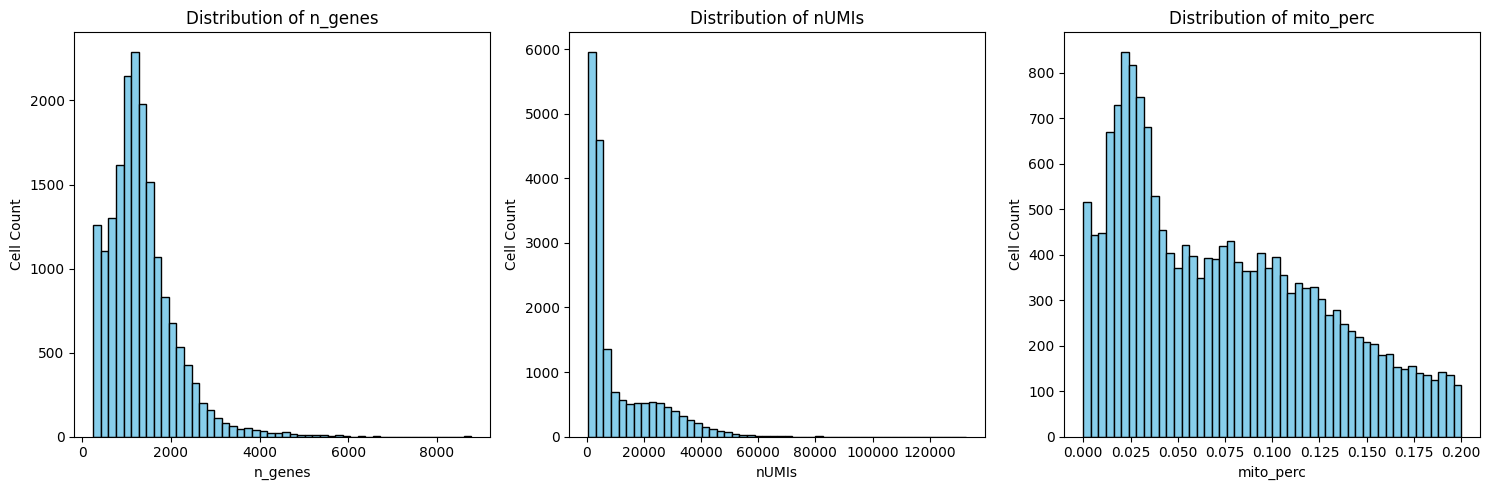

In [11]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/tmp/ipykernel_14364/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_14364/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_14364/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')


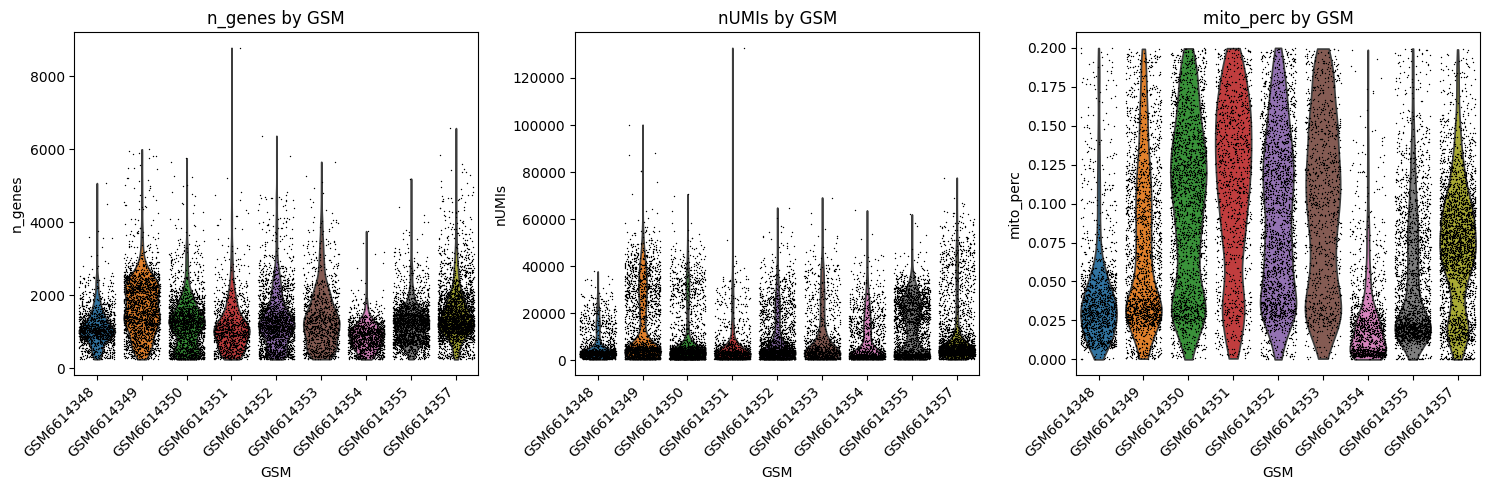

In [12]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [14]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 8908


In [15]:
print(adata.obs[['GSM', 'group']].drop_duplicates())

                                           GSM group
GSM6614348_HC5_AAACCTGAGGTCGGAT-1   GSM6614348    HC
GSM6614349_HC6_AAACGAAAGCAAGCCA-1   GSM6614349    HC
GSM6614350_HC7_AAACCCATCGCTTGAA-1   GSM6614350    HC
GSM6614351_HC8_AAACGAATCCATAGAC-1   GSM6614351    HC
GSM6614352_HC9_AAACCCAGTTCTTGTT-1   GSM6614352    HC
GSM6614353_HC10_AAACCCATCACCTGTC-1  GSM6614353    HC
GSM6614354_UC5_AAACCCAGTTCCCAAA-1   GSM6614354    UC
GSM6614355_UC6_AAACGAAAGTGGACGT-1   GSM6614355    UC
GSM6614357_UC7_AAACGAACACGCGCAT-1   GSM6614357    UC


## 保存质控后数据


In [16]:
import os
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "2_GSE214695_qc.h5ad"), compression='gzip')

## 降维聚类

In [17]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


结肠组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [18]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

Begin robust gene identification
After filtration, 13188/13188 genes are kept.     Among 13188 genes, 13188 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'JCHAIN', 'HBB', 'FTH1', 'MALAT1', 'IGHG2', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'PHGR1', 'ZG16', 'PLCG2', 'IGLL5', 'IGLC2', 'IGLC3', 'IGLC7']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 0.7071781158447266 seconds.
End of size normalization: 

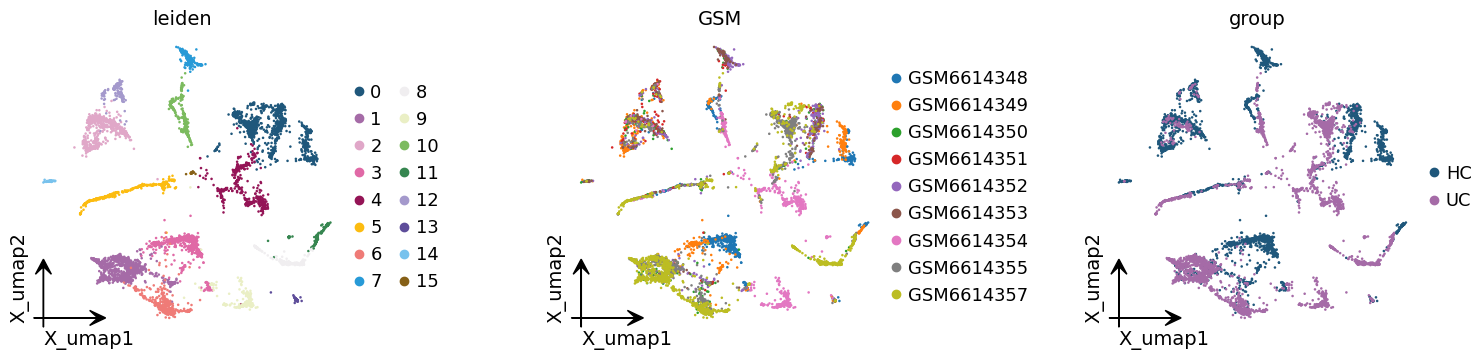

In [19]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

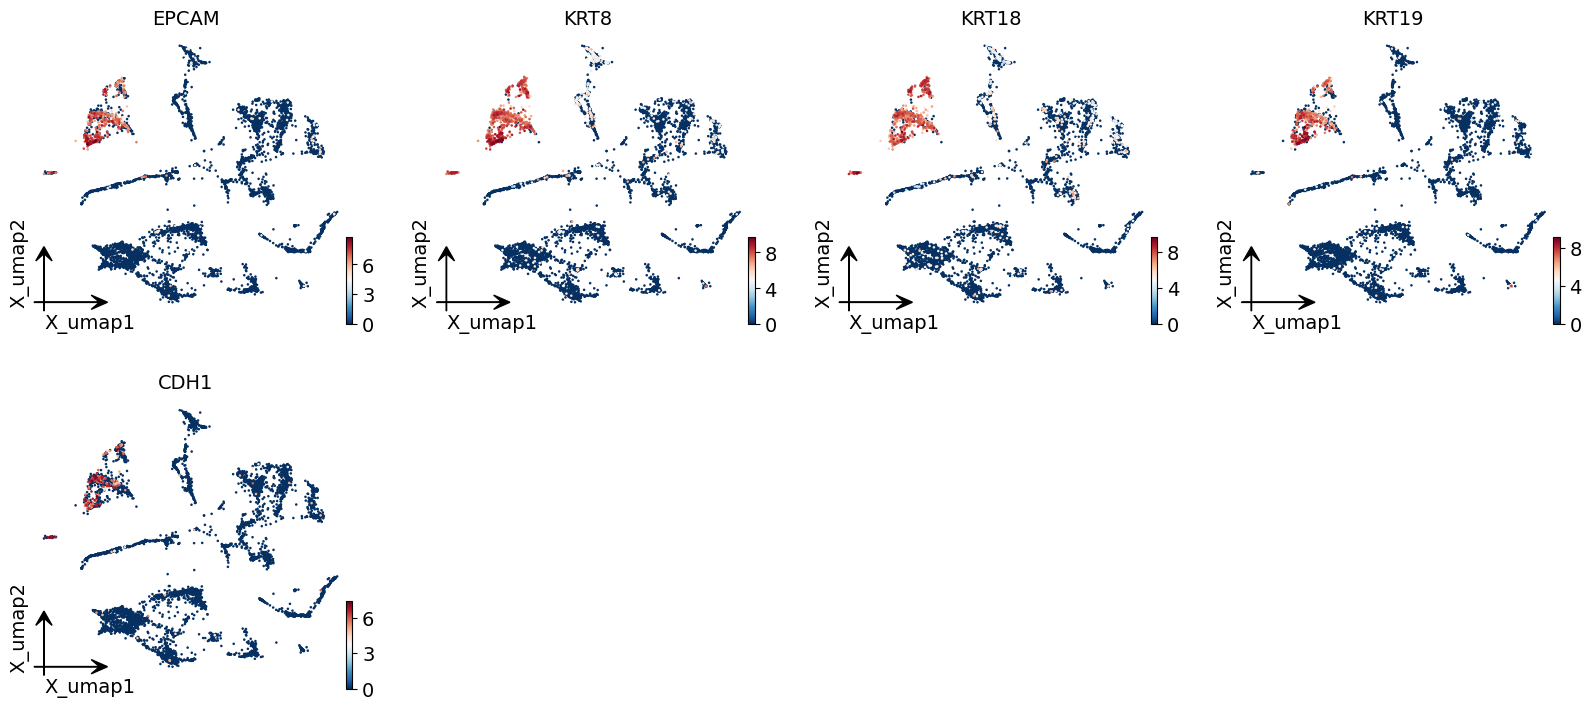

In [20]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

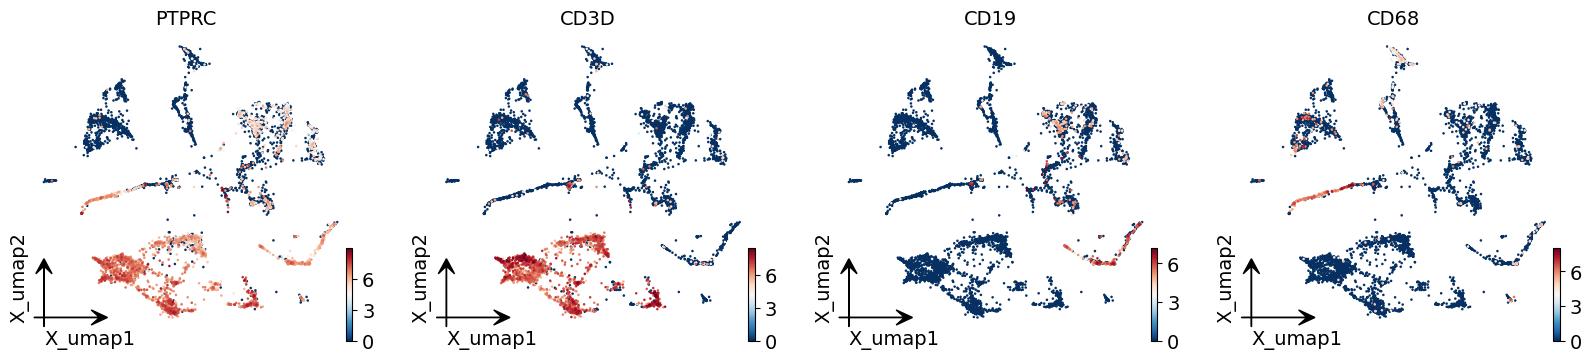

In [21]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

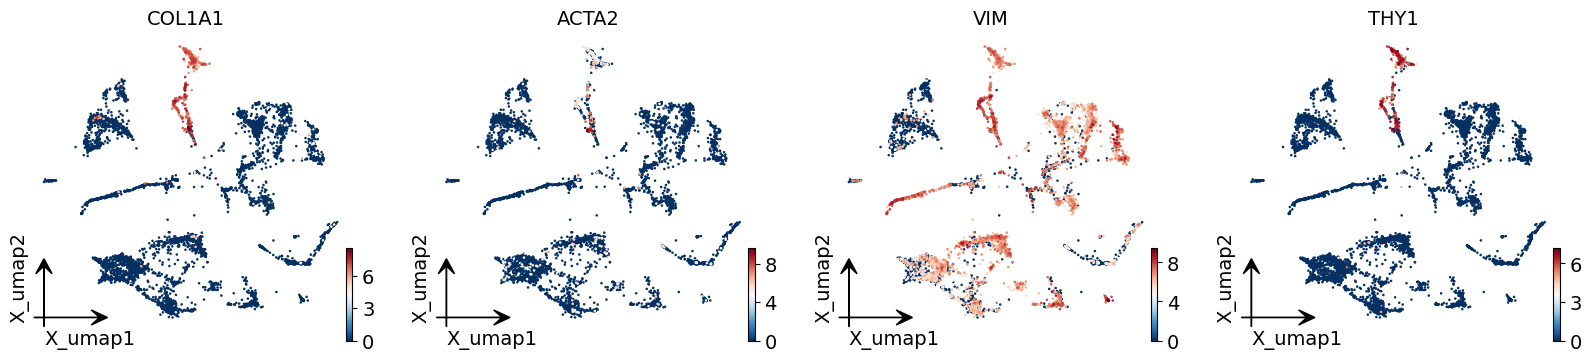

In [22]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [23]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

2025-11-04 13:41:50,958 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


...Begin using harmony to correct batch effect


2025-11-04 13:41:52,604 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-04 13:41:52,644 - harmonypy - INFO - Iteration 1 of 10
2025-11-04 13:41:53,943 - harmonypy - INFO - Iteration 2 of 10
2025-11-04 13:41:55,232 - harmonypy - INFO - Iteration 3 of 10
2025-11-04 13:41:56,456 - harmonypy - INFO - Iteration 4 of 10
2025-11-04 13:41:57,653 - harmonypy - INFO - Iteration 5 of 10
2025-11-04 13:41:58,601 - harmonypy - INFO - Converged after 5 iterations


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
🔍 [2025-11-04 13:41:59] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||||------------------------- 3057/16311 MiB (18.7%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


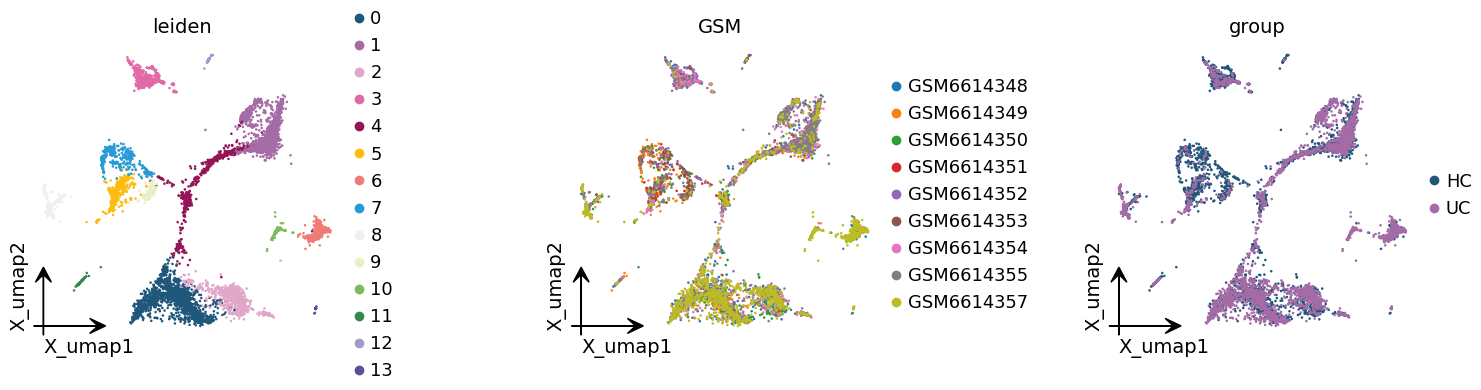

In [24]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

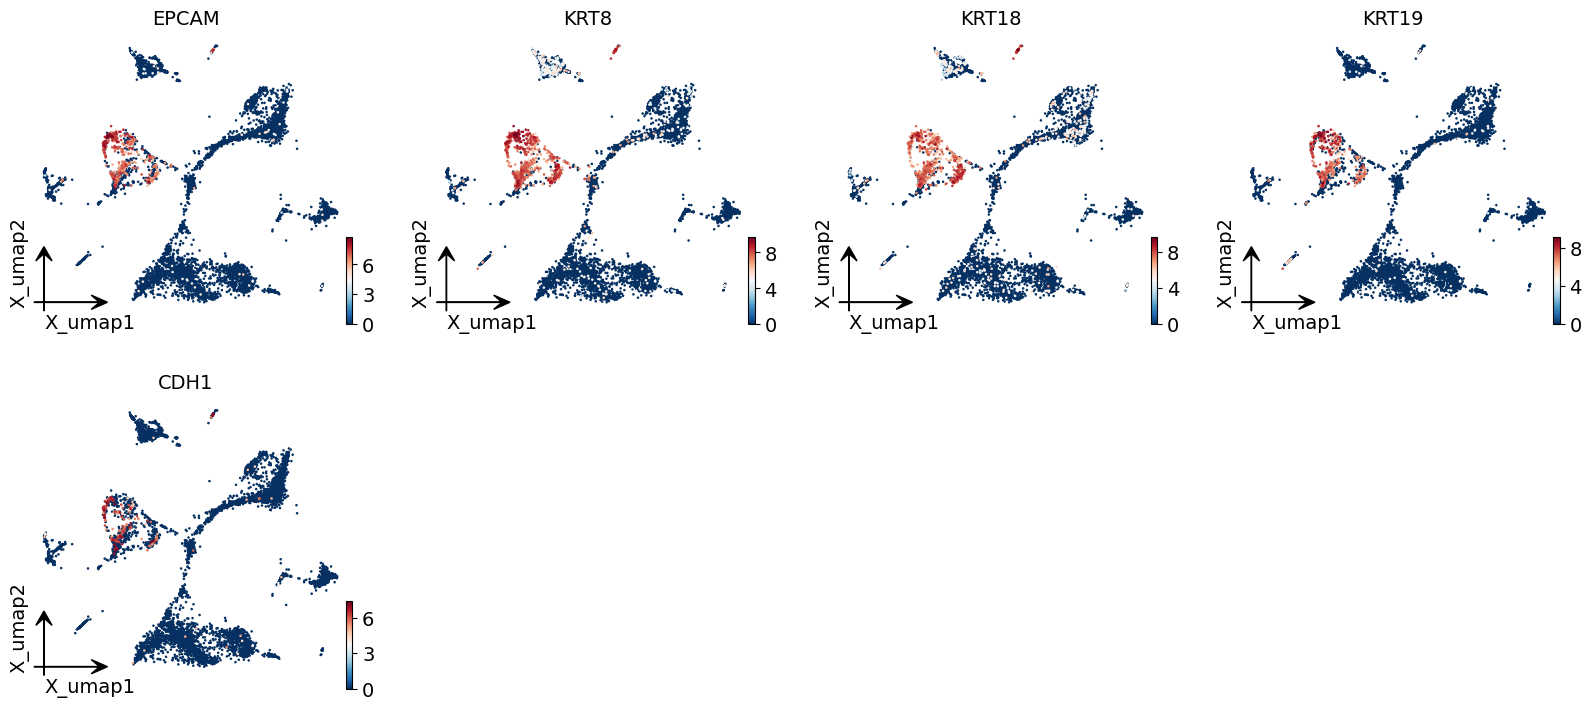

In [25]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

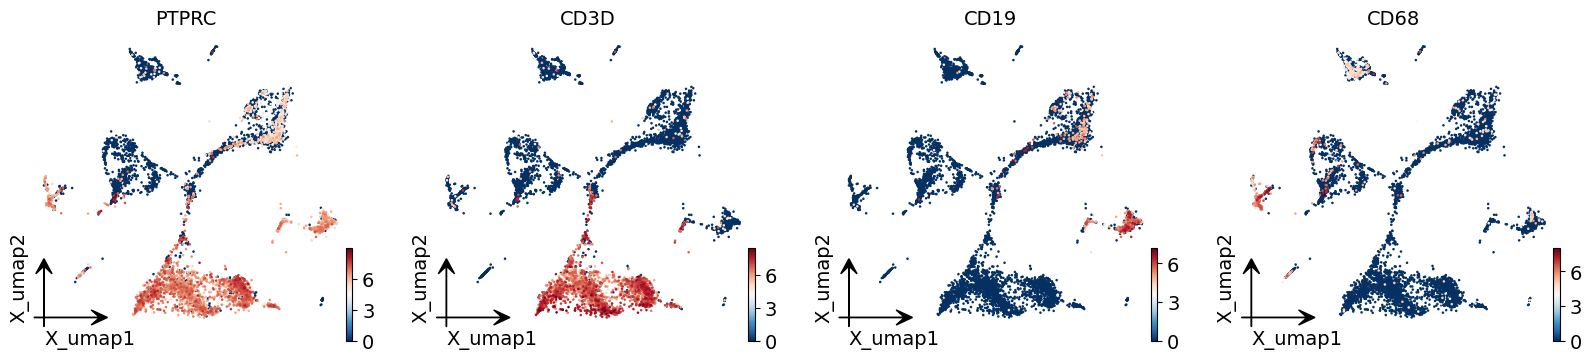

In [26]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

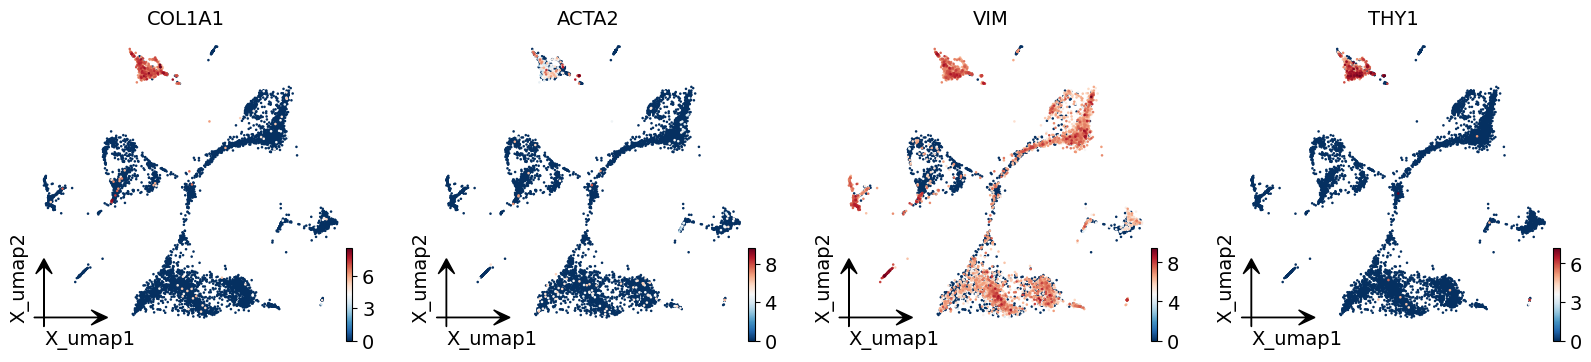

In [27]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

运行harmony之后明显更加均匀，但是难以判断是否掩盖了部分差异，有待考虑

## GPT自动注释

In [28]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


{'0': ['PTPRC',
  'TRBC2',
  'IL7R',
  'CD3E',
  'TRAC',
  'CD2',
  'CD3D',
  'KLRB1',
  'IL32',
  'SRGN'],
 '1': ['SPCS2',
  'MZB1',
  'FKBP11',
  'JCHAIN',
  'SPCS1',
  'SSR3',
  'DERL3',
  'SEC11C',
  'FKBP2',
  'SSR4'],
 '10': ['HMGB2',
  'TOP2A',
  'H2AFZ',
  'STMN1',
  'HMGN2',
  'PCLAF',
  'MKI67',
  'TUBB',
  'NUSAP1',
  'HMGB1'],
 '11': ['VIM',
  'LMNA',
  'FCER1G',
  'HPGDS',
  'MS4A2',
  'CPA3',
  'CLU',
  'TPSAB1',
  'TPSB2',
  'ANXA1'],
 '12': ['KRT8',
  'PSTPIP2',
  'ELF3',
  'KRT18',
  'PLCG2',
  'MALAT1',
  'LRMP',
  'LUC7L3',
  'COL27A1',
  'TPM1'],
 '13': ['ECSCR',
  'RNASE1',
  'IGFBP7',
  'PLVAP',
  'TM4SF1',
  'RAMP2',
  'CAV1',
  'SPARCL1',
  'GNG11',
  'IFITM3'],
 '2': ['PTPRC',
  'GZMA',
  'CST7',
  'TMSB4X',
  'CD3D',
  'IL32',
  'HLA-A',
  'CCL5',
  'HCST',
  'NKG7'],
 '3': ['CXCL14',
  'COL1A1',
  'C1R',
  'CALD1',
  'COL1A2',
  'TMEM176B',
  'C1S',
  'DCN',
  'COL3A1',
  'IFITM3'],
 '4': ['MZB1', 'JCHAIN', 'IGHA1', 'IGHA2', 'IGKC', 'DERL3'],
 '5': ['KRT8',
 

In [29]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'Plasma cell',
 '10': 'Proliferating cell',
 '11': 'Mast cell',
 '12': 'Epithelial cell',
 '13': 'Endothelial cell',
 '2': 'Cytotoxic T cell or NK cell',
 '3': 'Fibroblast',
 '4': 'Plasma cell',
 '5': 'Enterocyte',
 '6': 'Antigen-presenting cell',
 '7': 'Enterocyte',
 '8': 'Myeloid cell',
 '9': 'Goblet cell'}

In [30]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

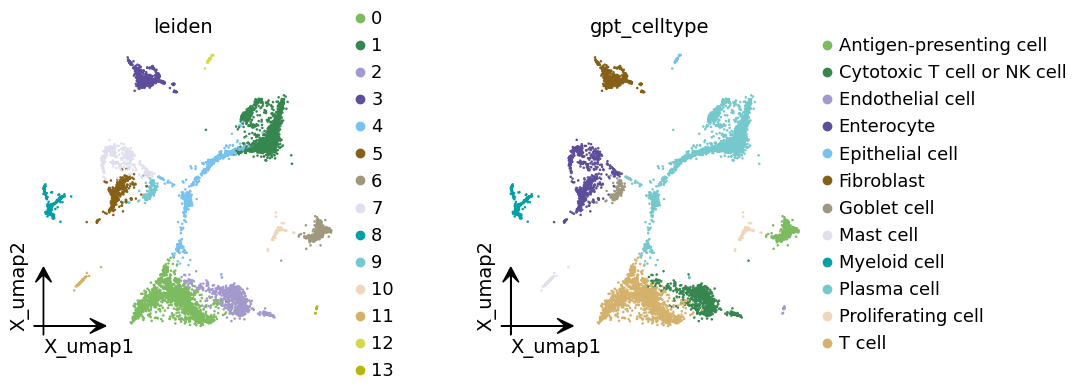

In [31]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [32]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Plasma cell                    28.075887
T cell                         20.498428
Enterocyte                     12.685227
Cytotoxic T cell or NK cell    11.910642
Fibroblast                      8.845981
Antigen-presenting cell         6.903907
Myeloid cell                    3.951504
Goblet cell                     2.694207
Proliferating cell              1.459362
Mast cell                       1.313426
Epithelial cell                 1.133812
Endothelial cell                0.527616
Name: proportion, dtype: float64


## 针对浆细胞的研究
浆细胞在所有细胞当中占比排第二，有点高

### 查看B细胞和浆细胞marker的表达情况

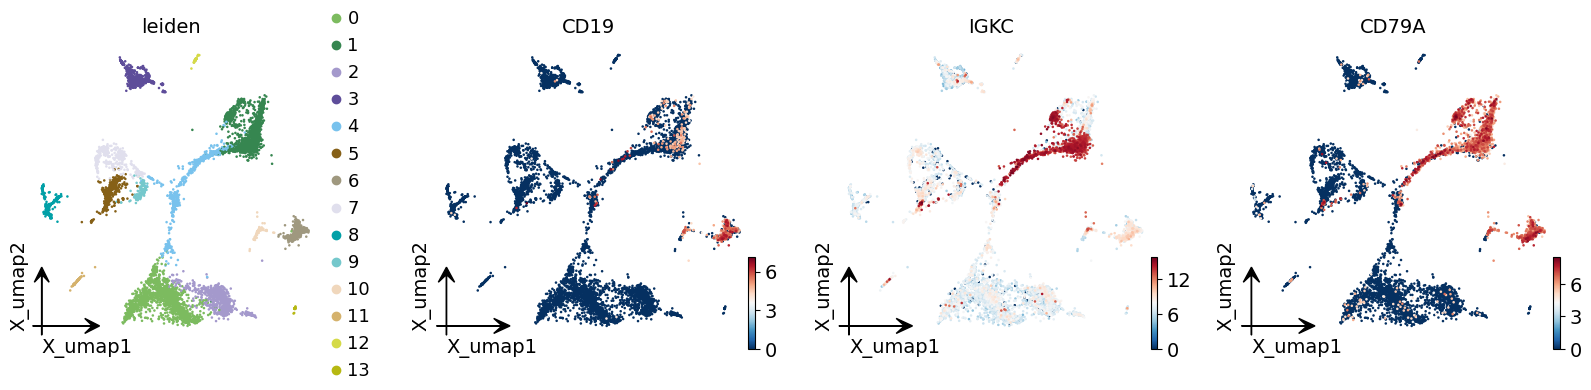

In [33]:
# B细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'CD19', 'IGKC', 'CD79A'], # PAX5 MS4A1
                frameon='small')

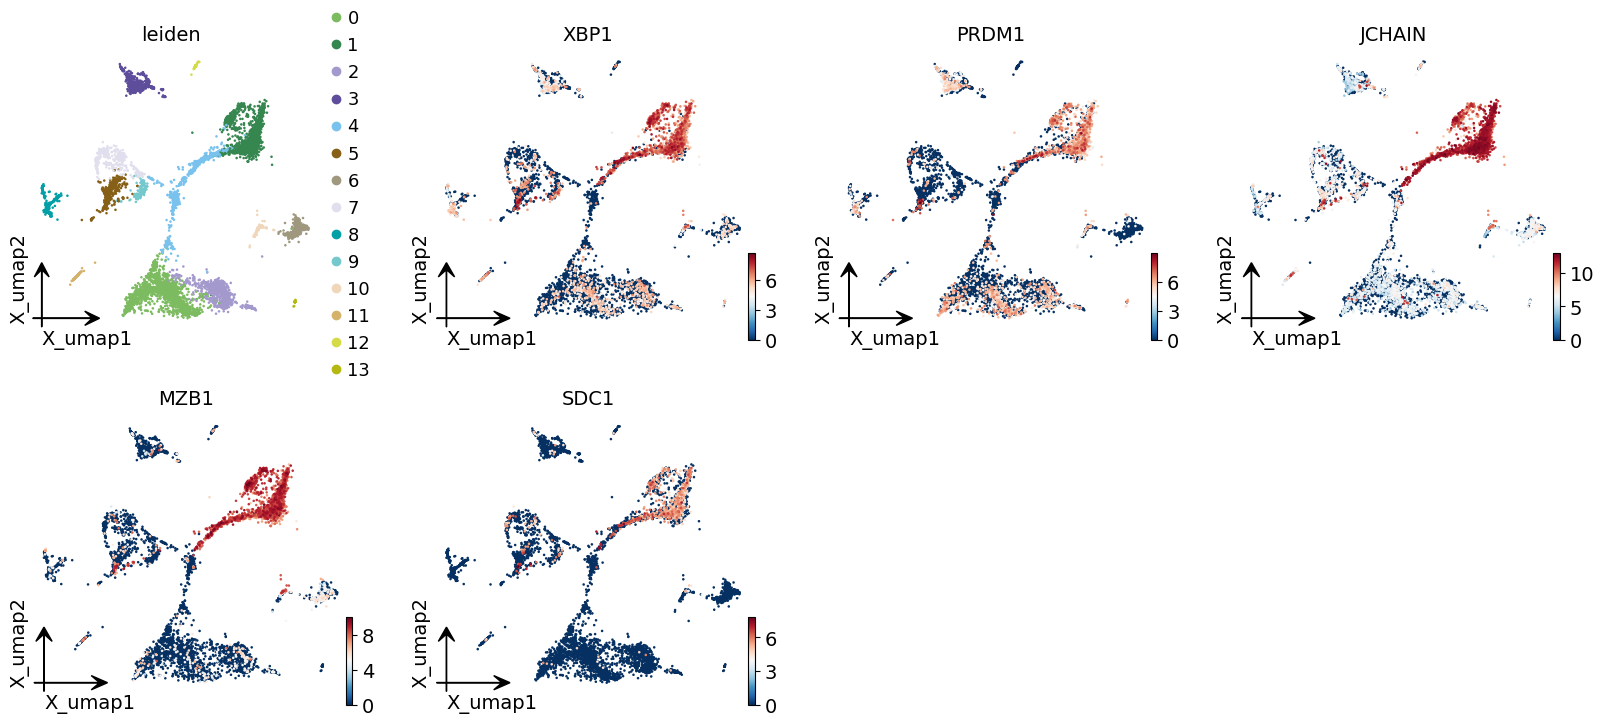

In [34]:
# 浆细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'XBP1', 'PRDM1', 'JCHAIN', 'MZB1', 'SDC1'],  
                frameon='small')

# 总结：
- 需要按样本去除批次效应
- 浆细胞正常